<a href="https://colab.research.google.com/github/Marlon-Sbardelatti/machine-learning/blob/feature%2Ftrabalho-01/trabalho-01/rmdemo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from enum import Enum


class Column(Enum):
    HOUSE_SIZE = "Tamanho da casa"
    ROOMS = "Número de quartos"
    HOUSE_PRICE = "Preço da casa"

In [6]:
import pandas as pd


data = pd.read_csv(
    "/content/data.csv", # a)
    names=[Column.HOUSE_SIZE.value, Column.ROOMS.value, Column.HOUSE_PRICE.value]
)

In [7]:
data.describe()

,Tamanho da casa,Número de quartos,Preço da casa
count,47.000000,47.000000,47.000000
mean,2000.680851,3.170213,340412.765957
std,794.702354,0.760982,125039.911223
min,852.000000,1.000000,169900.000000
25%,1432.000000,3.000000,249900.000000
50%,1888.000000,3.000000,299900.000000
75%,2269.000000,4.000000,384450.000000
max,4478.000000,5.000000,699900.000000


In [8]:
price_average = data[Column.HOUSE_PRICE.value].mean() # b)

smallest_house = data[Column.HOUSE_SIZE.value].min()
smallest_house_price = data.loc[data[Column.HOUSE_SIZE.value] == smallest_house, Column.HOUSE_PRICE.value].item()

most_expensive_house = data[Column.HOUSE_PRICE.value].max()
most_expensive_house_rooms = data.loc[data[Column.HOUSE_PRICE.value] == most_expensive_house, Column.ROOMS.value].item()

print("Média de preço:", price_average)
print("Preço da menor casa:", smallest_house_price)
print("Nº de quartos da casa mais cara:", most_expensive_house_rooms)

Média de preço: 340412.7659574468
Preço da menor casa: 179900.0
Nº de quartos da casa mais cara: 5


In [9]:
x = data[[Column.HOUSE_SIZE.value,Column.ROOMS.value]] # c)

y = data[Column.HOUSE_PRICE.value]

In [10]:
# Código da Fase 01 para Regressão Linear
from typing import List, Literal
import matplotlib.pyplot as plt
import math


def scatter_dispersion_graph(x_axis: List[float], y_axis: List[float]):
    plt.scatter(x_axis, y_axis)
    plt.xlabel("X")
    plt.ylabel("Y")


def average(axis: List[float]) -> float:
    return sum(axis) / len(axis)


def deviation(x_axis: List[float], y_axis: List[float], x_avg: float, y_avg: float) -> float:
    return sum((x - x_avg) * (y - y_avg) for x, y in zip(x_axis, y_axis))


def sum_squared_deviation_x(x_axis: List[float], x_avg: float) -> float:
    return sum((x - x_avg) ** 2 for x in x_axis)


def sum_squared_deviation_y(y_axis: List[float], y_avg: float) -> float:
    return sum((y - y_avg) ** 2 for y in y_axis)


def variance(
    x_axis: List[float], y_axis: List[float], x_avg: float, y_avg: float
) -> float:
    sx = sum_squared_deviation_x(x_axis, x_avg)
    sy = sum_squared_deviation_y(y_axis, y_avg)
    return math.sqrt(sx * sy)


def correlation(x_axis: List[float], y_axis: List[float]) -> float:
    x_avg = average(x_axis)
    y_avg = average(y_axis)

    dev = deviation(x_axis, y_axis, x_avg, y_avg)
    var = variance(x_axis, y_axis, x_avg, y_avg)

    return dev / var


def regression(x_axis: List[float], y_axis: List[float]):
    x_avg = average(x_axis)
    y_avg = average(y_axis)

    sum_dev = deviation(x_axis, y_axis, x_avg, y_avg)
    sqr_dev_x = sum_squared_deviation_x(x_axis, x_avg)

    b1 = sum_dev / sqr_dev_x
    b0 = y_avg - (b1 * x_avg)

    def unknown_function(x: float):
        return b0 + b1 * x

    y_model = [unknown_function(xi) for xi in x_axis]

    return b0, b1, y_model


def show_regression_graph(dataset: dict[Literal["x", "y"], List[float]]) -> None:
    x = dataset["x"]
    y = dataset["y"]

    x_avg = average(x)
    y_avg = average(y)

    sum_dev = deviation(x, y, x_avg, y_avg)
    sx = sum_squared_deviation_x(x, x_avg)
    sy = sum_squared_deviation_y(y, y_avg)

    # Correlação
    r = sum_dev / math.sqrt(sx * sy)

    # Regressão
    b0, b1, y_model = regression(x, y)

    # Gráfico
    scatter_dispersion_graph(x, y)
    plt.plot(x, y_model)

    plt.title(f"r = {r:.4f} | β0 = {b0:.4f} | β1 = {b1:.4f}")

    plt.show()
    plt.close()

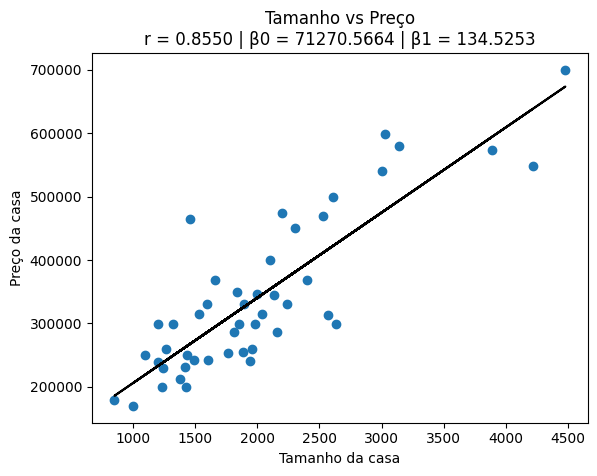

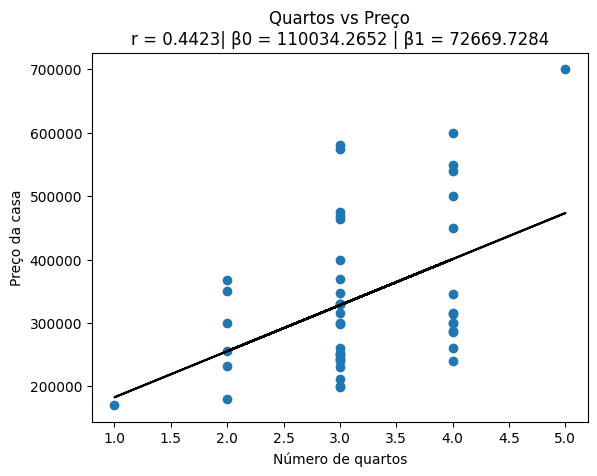

In [11]:
import matplotlib.pyplot as plt
import numpy as np


x_size = x[Column.HOUSE_SIZE.value] # d)
r_size_price = correlation(x_size, y)

b0_size, b1_size, y_size_model = regression(x_size, y)

plt.scatter(x_size, y)
plt.plot(x_size, y_size_model, color='black')

plt.xlabel(Column.HOUSE_SIZE.value)
plt.ylabel(Column.HOUSE_PRICE.value)
plt.title(f"Tamanho vs Preço\nr = {r_size_price:.4f} | β0 = {b0_size:.4f} | β1 = {b1_size:.4f}")
plt.show()

x_rooms = x[Column.ROOMS.value]
r_rooms_price = correlation(x_rooms, y)

b0_rooms, b1_rooms, y_rooms_model = regression(x_rooms, y)

plt.scatter(x_rooms, y)
plt.plot(x_rooms, y_rooms_model, color='black')

plt.xlabel(Column.ROOMS.value)
plt.ylabel(Column.HOUSE_PRICE.value)
plt.title(f"Quartos vs Preço\nr = {r_rooms_price:.4f}| β0 = {b0_rooms:.4f} | β1 = {b1_rooms:.4f}")
plt.show()


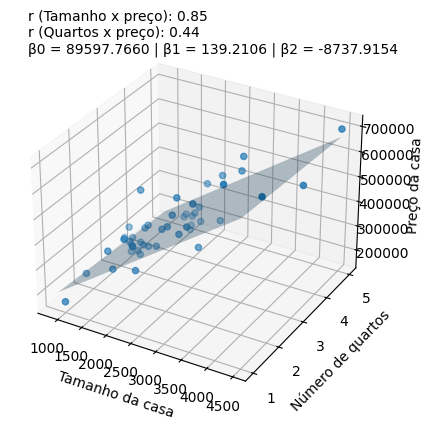

In [12]:
from typing import List, Tuple
from mpl_toolkits.mplot3d import Axes3D

'''
  Fórmula teórica: ŷ = β0*1 + β1*x1 + β2*x2
  Fórmula matricial: ŷ = X * β

  A função regmultipla retorna a matriz β (parâmetros) para multiplicação
  posterior pela matriz X (entradas para as variáveis independentes x),
  de modo a encontrar todas as previsões ŷ.
'''
def regmultipla(X: np.ndarray, y:np.ndarray) -> np.ndarray:
  # Adiciona coluna com 1 na matriz X, para multiplicação posterior por β0
  X = np.c_[np.ones(X.shape[0]), X] #   [x1, x2] -> [1, x1, x2]

  transposed_matrix = X.T # X^t
  inverted_matrix = np.linalg.inv(transposed_matrix @ X) # (X^t X)^(-1)
  beta = inverted_matrix @ transposed_matrix @ y # (X^t X)^(-1) * X^t * y

  def unknown_function(x_predict: np.ndarray) -> np.ndarray:
    x = np.c_[np.ones(x_predict.shape[0]), x_predict] # [x1, x2] -> [1, x1, x2]

    return x @ beta # 𝑦̂ = X*𝛽

  return beta, unknown_function

beta, y_model = regmultipla(x, y) # e)
b0, b1, b2 = beta

# Recupera valores de x1 ("Tamanho da casa") na matriz X
x1 = x[Column.HOUSE_SIZE.value]

# Recupera valores de x2 ("Número de quartos") na matriz x
x2 = x[Column.ROOMS.value]

figure = plt.figure()
ax = figure.add_subplot(111, projection='3d')

ax.scatter(x1, x2, y)

x1_surf, x2_surf = np.meshgrid(
    np.linspace(x1.min(), x1.max(), 10),
    np.linspace(x2.min(), x2.max(), 10)
)

X_grid = np.c_[x1_surf.ravel(), x2_surf.ravel()]
y_grid = y_model(X_grid)

# Calcula todas as previsões ŷ no espaço 3D, com base nos três eixos
y_surf = y_grid.reshape(x1_surf.shape) # f)

ax.plot_surface(x1_surf, x2_surf, y_surf, alpha=0.3)

ax.set_xlabel(Column.HOUSE_SIZE.value)
ax.set_ylabel(Column.ROOMS.value)
ax.set_zlabel(Column.HOUSE_PRICE.value)

# Correlação r1 de Tamanho x Preço
corr_size_price = np.corrcoef(x1, y)[0, 1]

# Correlação r2 de Quartos x Preço
corr_rooms_price = np.corrcoef(x2, y)[0, 1]

text= (
    f"r (Tamanho x preço): {corr_size_price:.2f}\n"
    f"r (Quartos x preço): {corr_rooms_price:.2f}\n"
    f"β0 = {b0:.4f} | β1 = {b1:.4f} | β2 = {b2:.4f}"
)

ax.text2D(0.05, 0.95, text, transform=ax.transAxes)

plt.show()

In [13]:
# Calcula individualmente uma previsão ŷ, sendo x1 o tamanho e x2 os quartos
def predict_multiple(size: float, rooms: int) -> float:
    return b0 + b1*size + b2*rooms

print(f"Preço para 3 quartos e tamanho 1650: {predict_multiple(1650, 3):.4f}")

print("Variação de preço pelo número de quartos")
for room_quantity in range(1,6):
    print(f"{room_quantity} quartos = {predict_multiple(1650, room_quantity):.4f}")

Preço para 3 quartos e tamanho 1650: 293081.5669
Variação de preço pelo número de quartos
1 quartos = 310557.3977
2 quartos = 301819.4823
3 quartos = 293081.5669
4 quartos = 284343.6515
5 quartos = 275605.7360


h.  Apesar da correlação positiva, ainda que baixa, entre o preço e o número quartos (0.44), o coeficiente na regressão múltipla (β2) apresentou um valor negativo de aproximadamente -8738. Esse coeficiente negativo indica uma relação reversa, onde **aumentar o número de quartos resulta em uma queda do preço**. Isso demonstra uma dependência do tamanho da casa, uma vez que, se mantido o tamanho — a exemplo de 1650 — mas aumentado o número de quartos, o espaço é divido em mais cômodos (menores), o que pode reduzir o valor percebido da casa.

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression() # i)

model.fit(x, y)

# Calcula parâmetros com base nas matrizes X e Y de entrada
b0_sklearn = model.intercept_
b1_sklearn, b2_sklearn = model.coef_

print(f"Com biblioteca: β0 = {b0_sklearn} | β1 = {b1_sklearn} | β2 = {b2_sklearn}")

beta, y_model = regmultipla(x, y)
b0, b1, b2 = beta

print(f"Manual:         β0 = {b0} | β1 = {b1} | β2 = {b2}")

Com biblioteca: β0 = 89597.76596099924 | β1 = 139.2106346503416 | β2 = -8737.915420187152
Manual:         β0 = 89597.76596099883 | β1 = 139.21063465034143 | β2 = -8737.91542018701


i. Os resultados demonstram alta aproximação entre os valores calculados manualmente e os calculados através da biblioteca, divergindo apenas na precisão numérica. O que demonstra que a implementação está correta, apesar de não ter uma precisão tão alta quanto o sklearn, que provavelmente utiliza técnicas mais robustas para garantir cálculos exatos.